In [663]:
import cv2
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import sys
from scipy.signal import find_peaks
from glob import glob
from PIL import Image

def imshow_cv2(img):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

def str2list(s):
    return list(map(float, s.split()))

def list2matrix(l):
    return np.array(l)


**1. Image Preprocessing**

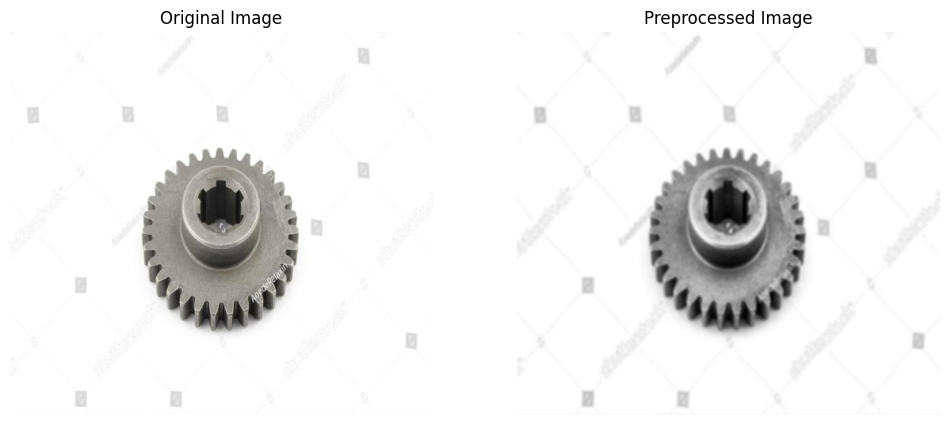

In [664]:
def preprocess_image(img, preprocessing_parameters):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 2. CLAHE Histogram Equalization
    clahe = cv2.createCLAHE(clipLimit=preprocessing_parameters['clipLimit'], tileGridSize=(8, 8))
    equalized = clahe.apply(gray)
    
    # 3. Gaussian Blurring
    sigma = preprocessing_parameters['sigma']
    blurred = cv2.GaussianBlur(equalized, (5, 5), sigma)
    
    return blurred

# Test the preprocessing function
image_path = './data/train/train_1.jpg'
img = cv2.imread(image_path)

preprocessing_parameters = {
    'clipLimit': 2.0,
    'sigma': 5.0
}

preprocessed_img = preprocess_image(img, preprocessing_parameters=preprocessing_parameters)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Preprocessed Image')
plt.imshow(preprocessed_img, cmap='gray')
plt.axis('off')
plt.show()


**5. Contour Detection**

Extract the contour of the gear using the following pipeline:
1. Binarize the image, with OTSU Thresholding obtaining black background and white subject (gear)
2. Use the findContours method from cv2 with the RETR_EXTERNAL mode to extract only the external contour of the gear

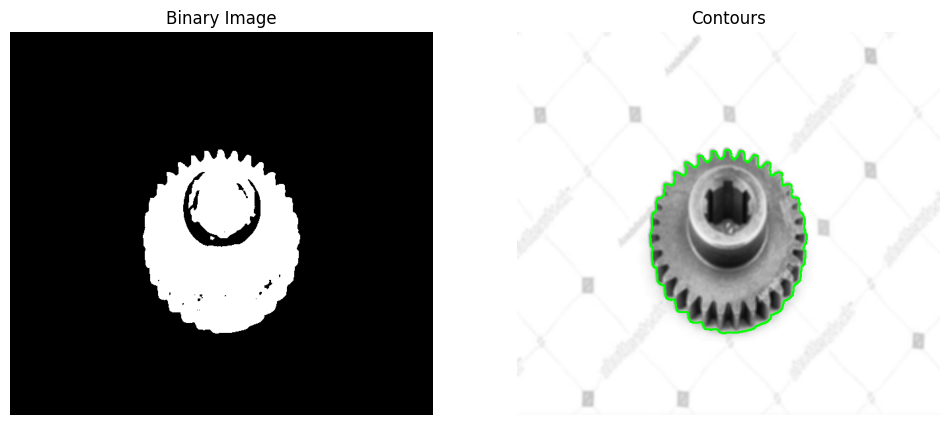

In [665]:
def extract_contours(image):
    # Binarize the image using OTSU Thresholding
    _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # invert the image if the background is not black (i.e. if the pixel at (1,1) is white)
    if binary[1, 1] == 255:
        binary = cv2.bitwise_not(binary)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))

    # Closing: fills small holes/gaps inside the gear body
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Opening: removes small isolated blobs outside the gear
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    
    # Find contours using RETR_EXTERNAL mode
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    gear_contour = max(contours, key=cv2.contourArea)

    
    return gear_contour, binary

# Test the contour extraction function
gear_contour, binary = extract_contours(preprocessed_img)
contour_img = cv2.cvtColor(preprocessed_img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contour_img, [gear_contour], -1, (0, 255, 0), 2)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Binary Image')
plt.imshow(binary, cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Contours')
plt.imshow(contour_img)
plt.axis('off')
plt.show()



In [666]:
# find contour peaks
def find_contour_peaks(dists, min_distance=5, min_prominence=1.5):
    # La 'prominence' filtra automaticamente i falsi picchi o le piccole increspature.
    # Dovrai calibrare il valore di min_prominence in base alla scala dei tuoi dati (es. pixel, distanze normalizzate, ecc.)
    peaks, properties = find_peaks(dists, distance=min_distance, prominence=min_prominence)
    
    # Convertiamo l'array in una lista per comodità
    final_peaks = list(peaks)

    # Aggiungiamo il primo punto del contorno se non è già stato individuato come picco
    if 0 not in final_peaks:
        final_peaks.insert(0, 0)
    
    return final_peaks, dists



def map_peaks_to_contour(contour, peaks, gear_center):
    # Array per salvare le coordinate (x, y) dei punti finali sui denti
    teeth_points = []

    # Quanti pixel vogliamo spostarci dalla punta estrema verso l'interno del dente?
    # Regola questo valore in base alla risoluzione della tua immagine e alla dimensione dei denti
    offset_inside = 10

    for peak_idx in peaks:
        # 1. Recupera le coordinate (x, y) della punta esatta dal contorno
        # Ricorda che i contorni di cv2 hanno shape (N, 1, 2)
        tip_x, tip_y = contour[peak_idx][0]
        
        # 2. Calcola il vettore che punta dalla punta del dente verso il baricentro
        dir_x = gear_center[0] - tip_x
        dir_y = gear_center[1] - tip_y
        
        # 3. Normalizza il vettore (rendi la sua lunghezza uguale a 1)
        length = np.hypot(dir_x, dir_y) # np.hypot è più rapido per la norma euclidea 2D
        
        if length > 0:
            dir_x_norm = dir_x / length
            dir_y_norm = dir_y / length
            
            # 4. Calcola le nuove coordinate traslate verso l'interno
            final_x = int(tip_x + (dir_x_norm * offset_inside))
            final_y = int(tip_y + (dir_y_norm * offset_inside))
            
            teeth_points.append((final_x, final_y))
        
    return teeth_points

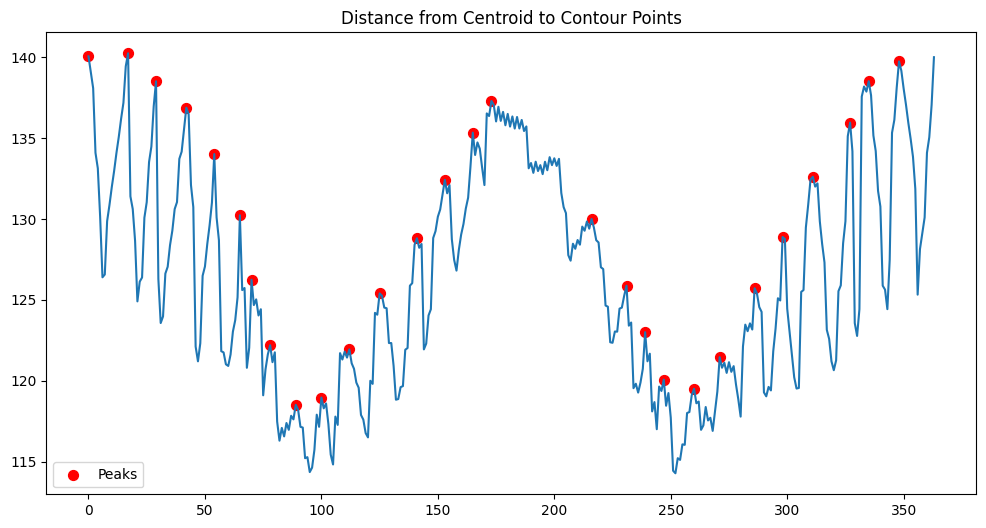

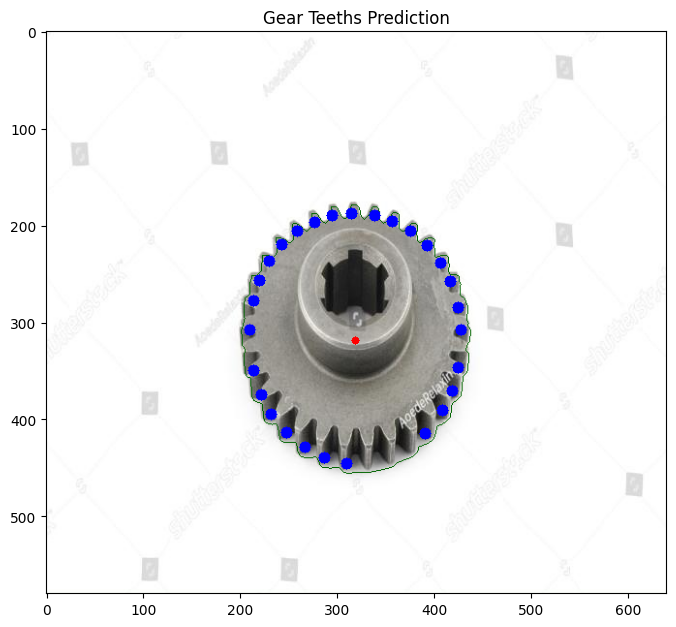

In [667]:
# plot the distances with peaks

M  = cv2.moments(gear_contour)
cx = int(M['m10'] / M['m00'])
cy = int(M['m01'] / M['m00'])

# Compute all distances from centroid to every contour point
dists = np.array([np.linalg.norm(p[0] - [cx, cy]) for p in gear_contour])

final_peaks, dists = find_contour_peaks(dists)
plt.figure(figsize=(12, 6))
plt.title('Distance from Centroid to Contour Points')
plt.plot(dists)
plt.scatter(final_peaks, dists[final_peaks], color='red', s=50, label='Peaks')
plt.legend()
plt.show()


# --- VISUALIZZAZIONE FINALE ---
# Usiamo l'immagine a colori per vedere bene i punti

result_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Disegniamo il contorno in verde scuro
cv2.drawContours(result_img, [gear_contour], -1, (0, 100, 0), 1)

# Disegniamo il baricentro in blu
cv2.circle(result_img, (cx, cy), 4, (255, 0, 0), -1)

teeth_points = map_peaks_to_contour(gear_contour, final_peaks, (cx, cy))

# Disegniamo i punti definitivi dei denti in rosso
for pt in teeth_points:
    cv2.circle(result_img, pt, 6, (0, 0, 255), -1)

plt.figure(figsize=(8, 8))
plt.title('Gear Teeths Prediction')
plt.imshow(result_img)
plt.show()

In [668]:
preprocessing_parameters = {
    'clipLimit': 2.0,
    'sigma': 5.0
}

def find_gear_theet(img):
    preprocessed_img = preprocess_image(img, preprocessing_parameters=preprocessing_parameters)
    gear_contour, binary = extract_contours(preprocessed_img)
    M  = cv2.moments(gear_contour)
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
    dists = np.array([np.linalg.norm(p[0] - [cx, cy]) for p in gear_contour])
    final_peaks, dists = find_contour_peaks(dists)
    teeth_points = map_peaks_to_contour(gear_contour, final_peaks, (cx, cy))
    
    return teeth_points

In [669]:
def score(solution, submission, debug_item=False):
    """
    this metric computes average precision and recall in theet detection
    """
    # TODO: You likely want to delete the row ID column, which Kaggle's system uses to align
    # the solution and submission before passing these dataframes to score().
    del solution['id']
    del submission['id']

    if submission.isnull().values.any():
        raise ParticipantVisibleError("Missing data in submission file")

    average_recall = 0
    average_precision = 0
    for i in range(len(solution )):
                bbox = solution['bbox'][i]
                
                theet=submission['bbox'][i]
                
                bbox=str2list(bbox)
                bbox=np.array(bbox).reshape(-1,4)
                
                theet=str2list(theet)
                theet = np.array(theet).reshape(-1,2).T
            
                true_positive = 0
               

                for j in range(len(bbox)):
                    x_min, y_min, x_max, y_max = bbox[j]
                    dx = (theet[0,:] - x_min) > 0
                    dx &= (x_max - theet[0,:]) > 0
                    dy = (theet[1,:] - y_min) > 0
                    dy &= (y_max - theet[1,:]) > 0
                    if(np.where(dx & dy)[0].shape[0]==1):
                        true_positive+=1

                false_positive=theet.shape[1]-true_positive    
                if(debug_item):
                    print('# of teeth=', len(bbox),', TP=',true_positive,', FP=',false_positive,': precision=',true_positive/theet.shape[1],' recall=',true_positive/len(bbox) )
                average_recall+=(true_positive/len(bbox))
                average_precision+=(true_positive/theet.shape[1])
        
    average_recall=average_recall/len(solution)
    average_precision=average_precision/len(solution)
    return average_recall,average_precision

# of teeth= 37 , TP= 32 , FP= 12 : precision= 0.7272727272727273  recall= 0.8648648648648649
# of teeth= 31 , TP= 21 , FP= 7 : precision= 0.75  recall= 0.6774193548387096
# of teeth= 30 , TP= 30 , FP= 0 : precision= 1.0  recall= 1.0
# of teeth= 27 , TP= 26 , FP= 3 : precision= 0.896551724137931  recall= 0.9629629629629629
# of teeth= 36 , TP= 26 , FP= 10 : precision= 0.7222222222222222  recall= 0.7222222222222222
# of teeth= 32 , TP= 24 , FP= 22 : precision= 0.5217391304347826  recall= 0.75
# of teeth= 66 , TP= 65 , FP= 1 : precision= 0.9848484848484849  recall= 0.9848484848484849
Recall=0.852, Precision=0.800


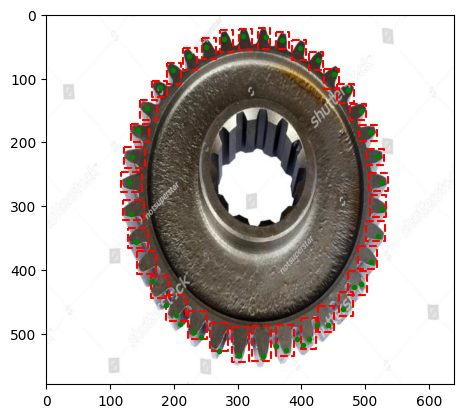

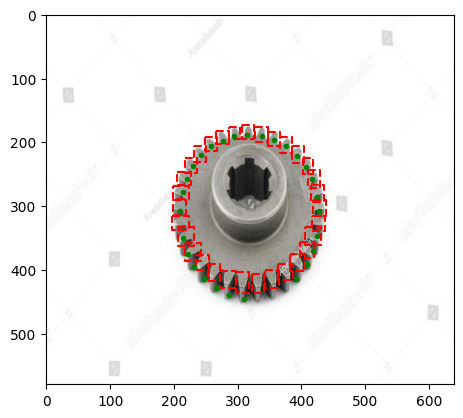

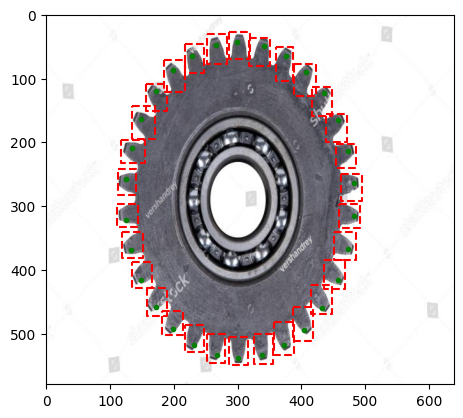

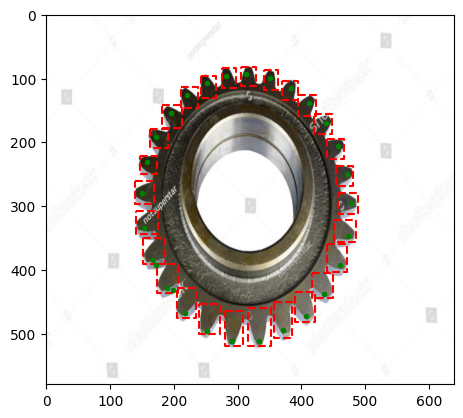

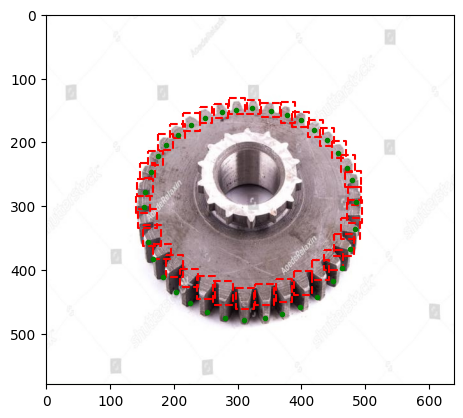

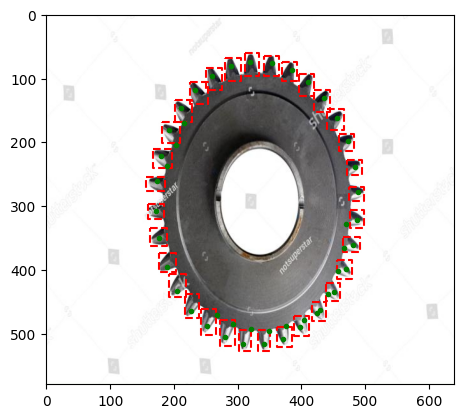

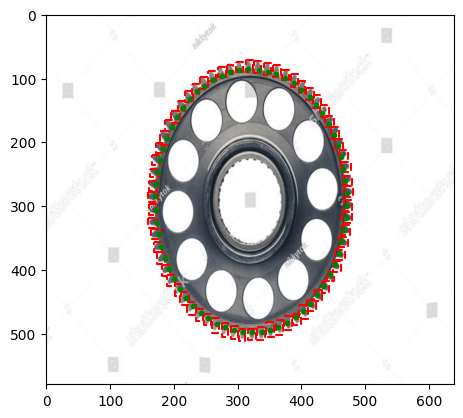

In [670]:
# test visualization and scoring metric of training set

train_PATH='./data/train'
df = pd.read_csv(os.path.join(train_PATH,'annotation.csv'))
solution_df = {'id': [], 'bbox': []}
for i in range(len(df)): # loop over training images
    path=os.path.join(train_PATH,df['id'][i])
    img = cv2.imread(path)
    
    #plot gear image and annotated bounding boxes around thetheet
    plt.figure()
    imshow_cv2(img)
    bbox = df['bbox'][i]
    bbox=str2list(bbox)
    bbox=np.array(bbox).reshape(-1,4)
    
    for j in range(len(bbox)):
        x_min, y_min, x_max, y_max = bbox[j]
        plt.plot([x_min,x_max,x_max,x_min,x_min],[y_min,y_min,y_max,y_max,y_min],'r--')

    # DECTOR TO BE DESIGNED
    theet = find_gear_theet(img)

    # reshape the theet list to a 2xN matrix for plotting and csv logging
    theet = list2matrix(theet)

    # plot theer coordinates for debugging
    plt.plot(theet[:,0],theet[:,1],'g.')

    # create solution csv for scoring
    solution_df['id'].append(df['id'][i])
    #flatten teeth coordinates to string for csv logging
    theet = " ".join(map(str, theet.flatten()))
    solution_df['bbox'].append(theet)
    

pd.DataFrame(solution_df).to_csv('train_solution.csv', index=False)

sf = pd.read_csv('train_solution.csv')
average_recall, average_precision = score(df,sf,debug_item=True)
print('Recall=%.3f, Precision=%.3f'%(average_recall,average_precision))

